In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Project paths

PROJECT_ROOT = Path("..")

PROCESSED_PATH = PROJECT_ROOT / "Data" / "processed"

print("Processed data path:")
print(PROCESSED_PATH.resolve())

Processed data path:
/Users/sayoojchandran/Desktop/End-to-End Banking Customer Intelligence & Loan Risk Platform/Data/processed


In [4]:
from pathlib import Path

PROCESSED_PATH = Path("../Data/processed")

print("Processed folder:")
print(PROCESSED_PATH.resolve())

print("\nFiles available:")
for file in sorted(PROCESSED_PATH.iterdir()):
    print("-", file.name)

Processed folder:
/Users/sayoojchandran/Desktop/End-to-End Banking Customer Intelligence & Loan Risk Platform/Data/processed

Files available:
- bank_marketing_clean.csv
- credit_default_clean.csv
- credit_model_comparison.csv
- credit_risk_profile.csv
- customer_clean.csv
- customer_credit_risk_predictions.csv
- customer_segment_summary.csv
- customer_segmentation.csv
- shap_feature_importance.csv
- shap_values_default_class.csv


In [5]:
# Find processed CSV files

processed_files = list(PROCESSED_PATH.glob("*.csv"))

print("Available processed CSV files:")
for file in processed_files:
    print("-", file.name)

Available processed CSV files:
- shap_feature_importance.csv
- credit_model_comparison.csv
- customer_segment_summary.csv
- credit_risk_profile.csv
- customer_clean.csv
- bank_marketing_clean.csv
- credit_default_clean.csv
- customer_credit_risk_predictions.csv
- shap_values_default_class.csv
- customer_segmentation.csv


In [7]:
# Find all processed CSV files

csv_files = list(PROCESSED_PATH.glob("*.csv"))

print("Processed CSV files:\n")

for file in csv_files:
    print(file.name)

Processed CSV files:

shap_feature_importance.csv
credit_model_comparison.csv
customer_segment_summary.csv
credit_risk_profile.csv
customer_clean.csv
bank_marketing_clean.csv
credit_default_clean.csv
customer_credit_risk_predictions.csv
shap_values_default_class.csv
customer_segmentation.csv


In [8]:
# Automatically identify the credit-risk prediction dataset

credit_predictions = None
credit_file = None

for file in csv_files:
    try:
        df_temp = pd.read_csv(file, nrows=5)

        columns_lower = [str(col).lower() for col in df_temp.columns]

        # Look for prediction/probability columns
        has_prediction = any(
            "prediction" in col or
            "probability" in col or
            "risk" in col
            for col in columns_lower
        )

        if has_prediction:
            credit_predictions = pd.read_csv(file)
            credit_file = file
            break

    except Exception:
        continue


if credit_predictions is not None:
    print("Credit risk dataset found:")
    print(credit_file.name)
    print("\nShape:", credit_predictions.shape)
    print("\nColumns:")
    print(credit_predictions.columns.tolist())
else:
    print("Credit risk prediction dataset was not found.")

Credit risk dataset found:
credit_risk_profile.csv

Shape: (4, 10)

Columns:
['risk_level', 'customers', 'avg_risk_score', 'avg_default_probability', 'avg_credit_limit', 'avg_age', 'avg_delinquent_months', 'avg_max_delinquency', 'avg_credit_utilization', 'avg_payment_to_bill']


In [9]:
# Load customer segmentation

customer_master = pd.read_csv(
    PROCESSED_PATH / "customer_segmentation.csv"
)

print("Customer segmentation loaded successfully.")
print("Shape:", customer_master.shape)
print("Columns:")
print(customer_master.columns.tolist())

Customer segmentation loaded successfully.
Shape: (884265, 25)
Columns:
['customerid', 'total_transactions', 'total_spending_inr', 'average_transaction_inr', 'maximum_transaction_inr', 'minimum_transaction_inr', 'average_account_balance_inr', 'maximum_account_balance_inr', 'last_transaction_date', 'first_transaction_date', 'gender', 'location', 'date_of_birth', 'age', 'recency_days', 'frequency', 'monetary_value_inr', 'activity_days', 'activity_months', 'transactions_per_month', 'recency_log', 'frequency_log', 'monetary_log', 'cluster', 'segment']


In [10]:
# Load SHAP feature importance

shap_importance = pd.read_csv(
    PROCESSED_PATH / "shap_feature_importance.csv"
)

print("SHAP feature importance loaded successfully.")
print("Shape:", shap_importance.shape)

SHAP feature importance loaded successfully.
Shape: (38, 2)


In [11]:
# Show all processed files with their sizes

print("FILES IN PROCESSED FOLDER")
print("=" * 70)

for file in sorted(PROCESSED_PATH.iterdir()):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"{file.name:<50} {size_mb:.2f} MB")

FILES IN PROCESSED FOLDER
bank_marketing_clean.csv                           3.53 MB
credit_default_clean.csv                           2.73 MB
credit_model_comparison.csv                        0.00 MB
credit_risk_profile.csv                            0.00 MB
customer_clean.csv                                 65.21 MB
customer_credit_risk_predictions.csv               0.51 MB
customer_segment_summary.csv                       0.00 MB
customer_segmentation.csv                          177.72 MB
shap_feature_importance.csv                        0.00 MB
shap_values_default_class.csv                      1.59 MB


In [12]:
# Inspect CSV files and identify their columns

print("\nCSV DATASET STRUCTURE")
print("=" * 70)

for file in sorted(PROCESSED_PATH.glob("*.csv")):
    try:
        temp = pd.read_csv(file, nrows=3)
        print(f"\n{file.name}")
        print("Columns:", temp.columns.tolist())
    except Exception as e:
        print(f"\n{file.name} -> Could not read: {e}")


CSV DATASET STRUCTURE

bank_marketing_clean.csv
Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

credit_default_clean.csv
Columns: ['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'default_payment_next_month']

credit_model_comparison.csv
Columns: ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

credit_risk_profile.csv
Columns: ['risk_level', 'customers', 'avg_risk_score', 'avg_default_probability', 'avg_credit_limit', 'avg_age', 'avg_delinquent_months', 'avg_max_delinquency', 'avg_credit_utilization', 'avg_payment_to_bill']

customer_clean.csv
Columns: ['transactionid', 'customerid', 'customerdob', 'custgender', 'custlocation'

In [13]:
# Load final analytical datasets

customer_master = pd.read_csv(
    PROCESSED_PATH / "customer_segmentation.csv"
)

credit_predictions = pd.read_csv(
    PROCESSED_PATH / "customer_credit_risk_predictions.csv"
)

shap_importance = pd.read_csv(
    PROCESSED_PATH / "shap_feature_importance.csv"
)

print("All analytical datasets loaded successfully.")

print("\nCustomer Intelligence:")
print(customer_master.shape)

print("\nCredit Risk:")
print(credit_predictions.shape)

print("\nSHAP:")
print(shap_importance.shape)

All analytical datasets loaded successfully.

Customer Intelligence:
(884265, 25)

Credit Risk:
(6000, 11)

SHAP:
(38, 2)


In [14]:
print("CUSTOMER INTELLIGENCE DATA")
print("=" * 70)

display(
    customer_master[
        [
            "customerid",
            "total_transactions",
            "total_spending_inr",
            "average_account_balance_inr",
            "recency_days",
            "frequency",
            "monetary_value_inr",
            "segment"
        ]
    ].head(10)
)

CUSTOMER INTELLIGENCE DATA


,customerid,total_transactions,total_spending_inr,average_account_balance_inr,recency_days,frequency,monetary_value_inr,segment
0,C1010011,2,"5,106.00","76,340.63",25,2,"5,106.00",High-Value Active Customers
1,C1010012,1,"1,499.00","24,204.49",68,1,"1,499.00",High-Value At-Risk Customers
2,C1010014,2,"1,455.00","100,112.95",75,2,"1,455.00",High-Value Active Customers
3,C1010018,1,30.00,496.18,36,1,30.00,Low-Value Dormant Customers
4,C1010024,1,"5,000.00","87,058.65",64,1,"5,000.00",High-Value At-Risk Customers
5,C1010028,1,557.00,"296,828.37",53,1,557.00,Recent Moderate-Spend Customers
6,C1010031,2,"1,864.00","5,200.15",78,2,"1,864.00",High-Value Active Customers
7,C1010035,2,750.00,"192,648.76",55,2,750.00,High-Value Active Customers
8,C1010036,1,208.00,"355,430.17",56,1,208.00,Low-Value Dormant Customers
9,C1010037,1,"19,680.00","95,859.17",73,1,"19,680.00",High-Value At-Risk Customers


In [15]:
print("CREDIT RISK DATA")
print("=" * 70)

display(
    credit_predictions[
        [
            "id",
            "limit_bal",
            "age",
            "num_delinquent_months",
            "max_delinquency",
            "average_credit_utilization",
            "payment_to_bill_ratio",
            "default_probability",
            "risk_score",
            "risk_level"
        ]
    ].head(10)
)

CREDIT RISK DATA


,id,limit_bal,age,num_delinquent_months,max_delinquency,average_credit_utilization,payment_to_bill_ratio,default_probability,risk_score,risk_level
0,1957,220000,42,6,2,0.01,0.00,0.99,98.77,Very High
1,27537,250000,51,6,3,0.01,0.00,0.99,98.71,Very High
2,28055,20000,32,6,7,0.12,0.00,0.98,98.49,Very High
3,28748,50000,28,6,7,0.05,0.00,0.98,98.48,Very High
4,20722,20000,37,6,7,0.12,0.00,0.98,98.27,Very High
5,29771,20000,31,6,7,0.12,0.00,0.98,98.13,Very High
6,16789,30000,37,6,7,0.08,0.00,0.98,97.88,Very High
7,6272,10000,23,6,7,0.23,0.00,0.98,97.65,Very High
8,13740,40000,43,6,7,0.06,0.00,0.98,97.62,Very High
9,29727,60000,36,6,7,0.04,0.00,0.98,97.52,Very High


In [16]:
# Customer Intelligence KPIs

customer_kpis = {
    "total_customers": customer_master["customerid"].nunique(),
    "total_transactions": customer_master["total_transactions"].sum(),
    "total_transaction_value_inr": customer_master["total_spending_inr"].sum(),
    "average_customer_spending_inr": customer_master["total_spending_inr"].mean(),
    "average_account_balance_inr": customer_master["average_account_balance_inr"].mean(),
    "average_transaction_frequency": customer_master["frequency"].mean()
}

print("CUSTOMER INTELLIGENCE KPIs")
print("=" * 70)

for key, value in customer_kpis.items():
    print(f"{key}: {value:,.2f}")

CUSTOMER INTELLIGENCE KPIs
total_customers: 884,265.00
total_transactions: 1,048,567.00
total_transaction_value_inr: 1,650,795,731.57
average_customer_spending_inr: 1,866.86
average_account_balance_inr: 114,976.29
average_transaction_frequency: 1.19


In [17]:
# Segment-level business summary

segment_kpis = (
    customer_master
    .groupby("segment")
    .agg(
        customers=("customerid", "count"),
        total_transactions=("total_transactions", "sum"),
        total_spending_inr=("total_spending_inr", "sum"),
        avg_spending_inr=("total_spending_inr", "mean"),
        avg_balance_inr=("average_account_balance_inr", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean")
    )
    .reset_index()
)

segment_kpis["customer_percentage"] = (
    segment_kpis["customers"]
    / len(customer_master)
    * 100
).round(2)

display(
    segment_kpis.round(2)
)

,segment,customers,total_transactions,total_spending_inr,avg_spending_inr,avg_balance_inr,avg_recency_days,avg_frequency,customer_percentage
0,High-Value Active Customers,142391,305239,"479,851,125.39","3,369.95","117,290.57",47.96,2.14,16.10
1,High-Value At-Risk Customers,279139,279139,"927,748,152.04","3,323.61","166,915.33",65.22,1.00,31.57
2,Low-Value Dormant Customers,255319,255438,"32,980,497.59",129.17,"61,637.92",61.55,1.00,28.87
3,Recent Moderate-Spend Customers,203762,203762,"200,743,657.08",985.19,"109,208.99",40.03,1.00,23.04
4,Recently Active Customers,3654,4989,"9,472,299.47","2,592.31","105,593.28",0.00,1.37,0.41


In [18]:
# Credit Risk KPIs

credit_kpis = {
    "customers_evaluated": len(credit_predictions),
    "average_risk_score": credit_predictions["risk_score"].mean(),
    "average_default_probability": credit_predictions["default_probability"].mean(),
    "high_risk_customers": credit_predictions[
        credit_predictions["risk_level"].isin(
            ["High", "Very High"]
        )
    ].shape[0],
    "very_high_risk_customers": credit_predictions[
        credit_predictions["risk_level"] == "Very High"
    ].shape[0]
}

print("CREDIT RISK KPIs")
print("=" * 70)

for key, value in credit_kpis.items():
    print(f"{key}: {value:,.2f}")

CREDIT RISK KPIs
customers_evaluated: 6,000.00
average_risk_score: 39.58
average_default_probability: 0.40
high_risk_customers: 1,600.00
very_high_risk_customers: 696.00


In [19]:
# Credit risk distribution

risk_summary = (
    credit_predictions["risk_level"]
    .value_counts()
    .reindex(
        ["Low", "Moderate", "High", "Very High"],
        fill_value=0
    )
    .to_frame("customers")
)

risk_summary["percentage"] = (
    risk_summary["customers"]
    / len(credit_predictions)
    * 100
).round(2)

display(risk_summary)

,customers,percentage
risk_level,,
Low,1864,31.07
Moderate,2536,42.27
High,904,15.07
Very High,696,11.60


In [20]:
# Top credit-risk drivers

top_risk_drivers = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(top_risk_drivers)

,feature,mean_abs_shap
0,max_delinquency,0.04
1,pay_0,0.03
2,avg_delinquency,0.03
3,num_delinquent_months,0.03
4,recent_delinquency,0.03
5,maximum_credit_utilization,0.01
6,average_credit_utilization,0.01
7,limit_bal,0.01
8,total_payment_amount,0.01
9,pay_2,0.01


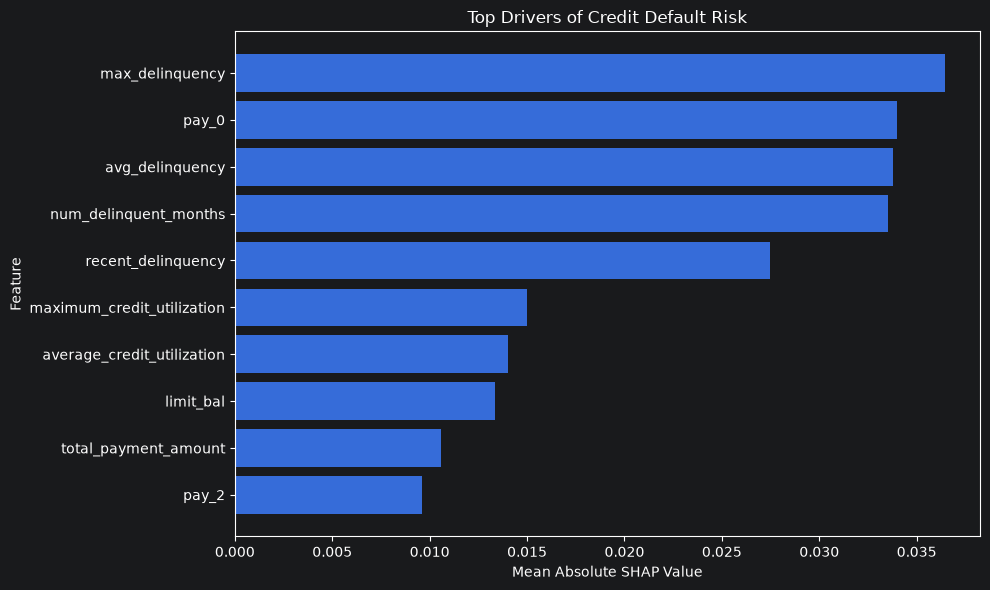

In [21]:
# Top credit-risk drivers visualization

plot_data = top_risk_drivers.sort_values(
    "mean_abs_shap"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["feature"],
    plot_data["mean_abs_shap"]
)

plt.title("Top Drivers of Credit Default Risk")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [22]:
# Save executive analytics outputs

segment_kpis.to_csv(
    PROCESSED_PATH / "banking_segment_kpis.csv",
    index=False
)

risk_summary.to_csv(
    PROCESSED_PATH / "banking_risk_summary.csv"
)

top_risk_drivers.to_csv(
    PROCESSED_PATH / "banking_top_risk_drivers.csv",
    index=False
)

print("Banking analytics outputs saved successfully.")

Banking analytics outputs saved successfully.


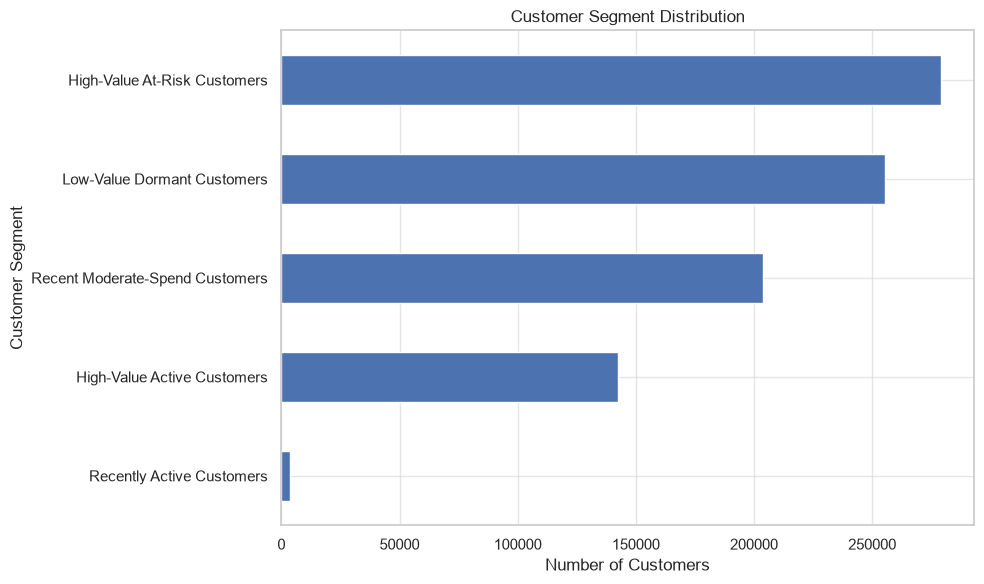

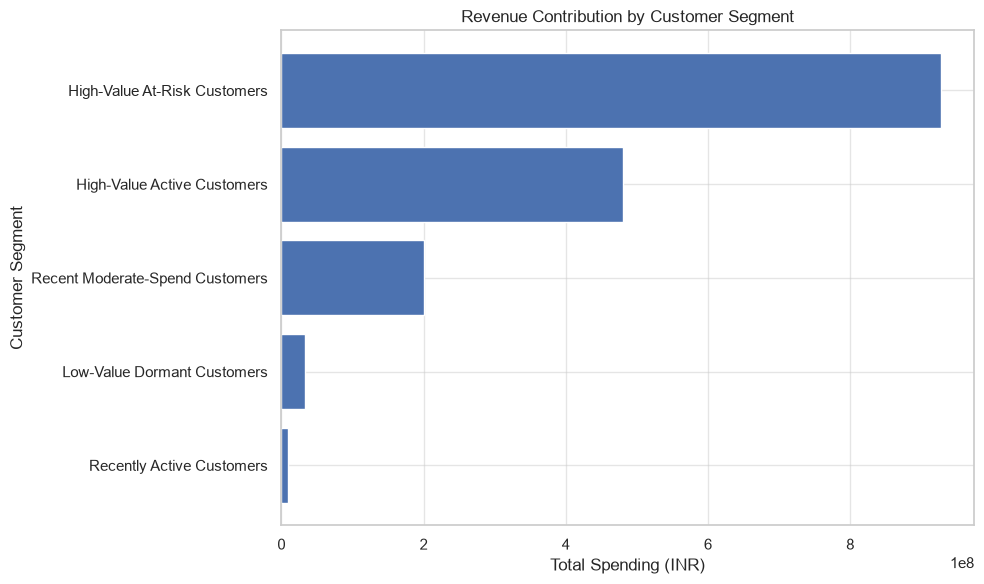

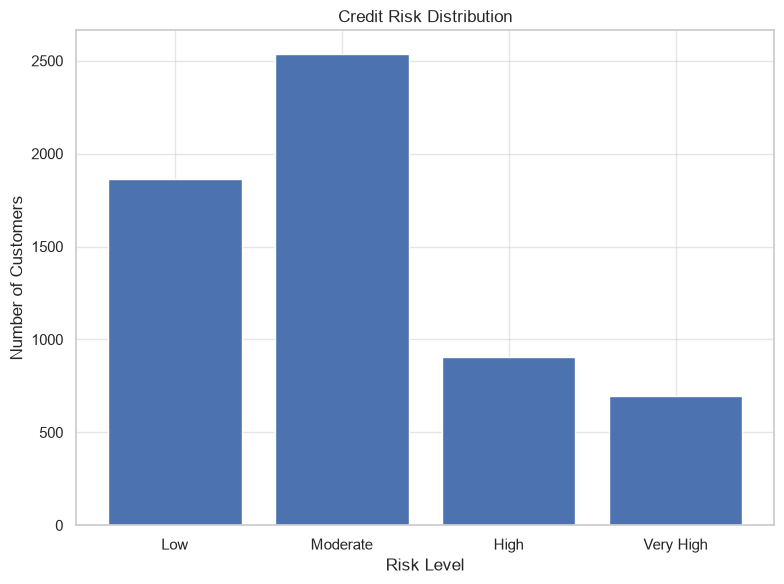

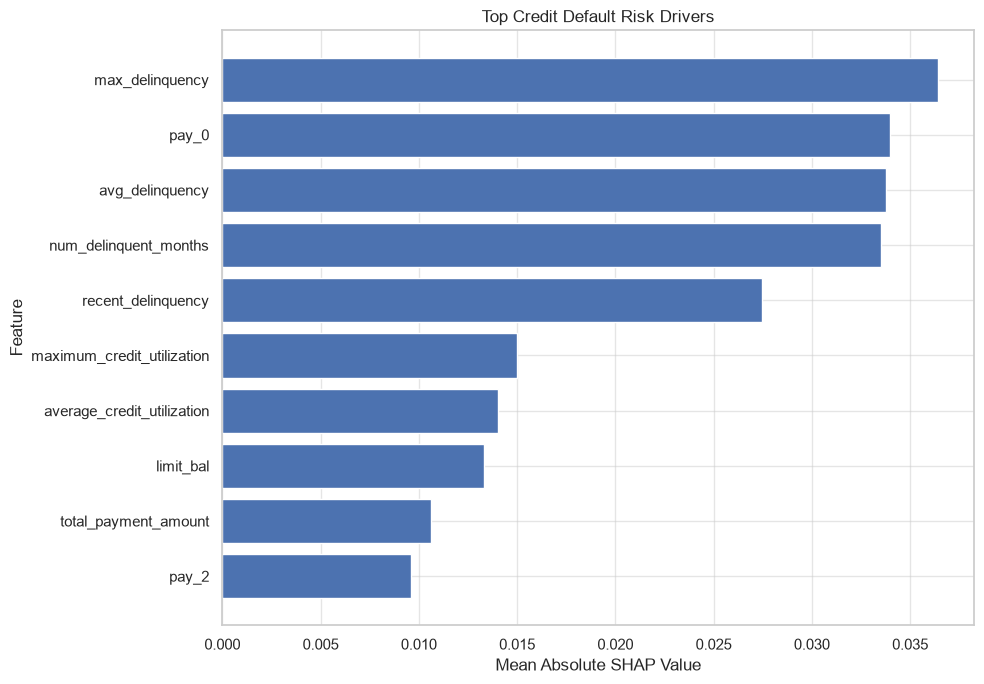

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# -----------------------------
# 1. Customer Segment Distribution
# -----------------------------
plt.figure(figsize=(10, 6))

segment_plot = (
    customer_master["segment"]
    .value_counts()
    .sort_values(ascending=True)
)

segment_plot.plot(kind="barh")

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(
    "customer_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 2. Segment Revenue Contribution
# -----------------------------
plt.figure(figsize=(10, 6))

revenue_plot = (
    segment_kpis
    .sort_values("total_spending_inr", ascending=True)
)

plt.barh(
    revenue_plot["segment"],
    revenue_plot["total_spending_inr"]
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Spending (INR)")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig(
    "segment_revenue_contribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 3. Credit Risk Distribution
# -----------------------------
plt.figure(figsize=(8, 6))

risk_order = ["Low", "Moderate", "High", "Very High"]

risk_plot = (
    risk_summary
    .reindex(risk_order)
)

plt.bar(
    risk_plot.index,
    risk_plot["customers"]
)

plt.title("Credit Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.savefig(
    "credit_risk_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# -----------------------------
# 4. Top Credit Risk Drivers
# -----------------------------
plt.figure(figsize=(10, 7))

driver_plot = (
    top_risk_drivers
    .sort_values("mean_abs_shap", ascending=True)
)

plt.barh(
    driver_plot["feature"],
    driver_plot["mean_abs_shap"]
)

plt.title("Top Credit Default Risk Drivers")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "top_credit_risk_drivers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
executive_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Transactions",
        "Total Transaction Value (INR)",
        "Average Customer Spending (INR)",
        "Average Account Balance (INR)",
        "Average Transaction Frequency",
        "Credit Customers Evaluated",
        "Average Credit Risk Score",
        "Average Default Probability",
        "High + Very High Risk Customers",
        "Very High Risk Customers"
    ],
    "Value": [
        customer_kpis["total_customers"],
        customer_kpis["total_transactions"],
        customer_kpis["total_transaction_value_inr"],
        customer_kpis["average_customer_spending_inr"],
        customer_kpis["average_account_balance_inr"],
        customer_kpis["average_transaction_frequency"],
        credit_kpis["customers_evaluated"],
        credit_kpis["average_risk_score"],
        credit_kpis["average_default_probability"],
        credit_kpis["high_risk_customers"],
        credit_kpis["very_high_risk_customers"]
    ]
})

executive_summary

,Metric,Value
0,Total Customers,"884,265.00"
1,Total Transactions,"1,048,567.00"
2,Total Transaction Value (INR),"1,650,795,731.57"
3,Average Customer Spending (INR),"1,866.86"
4,Average Account Balance (INR),"114,976.29"
5,Average Transaction Frequency,1.19
6,Credit Customers Evaluated,"6,000.00"
7,Average Credit Risk Score,39.58
8,Average Default Probability,0.40
9,High + Very High Risk Customers,"1,600.00"


In [25]:
executive_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Transactions",
        "Total Transaction Value (INR)",
        "Average Customer Spending (INR)",
        "Average Account Balance (INR)",
        "Average Transaction Frequency",
        "Credit Customers Evaluated",
        "Average Credit Risk Score",
        "Average Default Probability",
        "High + Very High Risk Customers",
        "Very High Risk Customers"
    ],
    "Value": [
        customer_kpis["total_customers"],
        customer_kpis["total_transactions"],
        customer_kpis["total_transaction_value_inr"],
        customer_kpis["average_customer_spending_inr"],
        customer_kpis["average_account_balance_inr"],
        customer_kpis["average_transaction_frequency"],
        credit_kpis["customers_evaluated"],
        credit_kpis["average_risk_score"],
        credit_kpis["average_default_probability"],
        credit_kpis["high_risk_customers"],
        credit_kpis["very_high_risk_customers"]
    ]
})

executive_summary

,Metric,Value
0,Total Customers,"884,265.00"
1,Total Transactions,"1,048,567.00"
2,Total Transaction Value (INR),"1,650,795,731.57"
3,Average Customer Spending (INR),"1,866.86"
4,Average Account Balance (INR),"114,976.29"
5,Average Transaction Frequency,1.19
6,Credit Customers Evaluated,"6,000.00"
7,Average Credit Risk Score,39.58
8,Average Default Probability,0.40
9,High + Very High Risk Customers,"1,600.00"


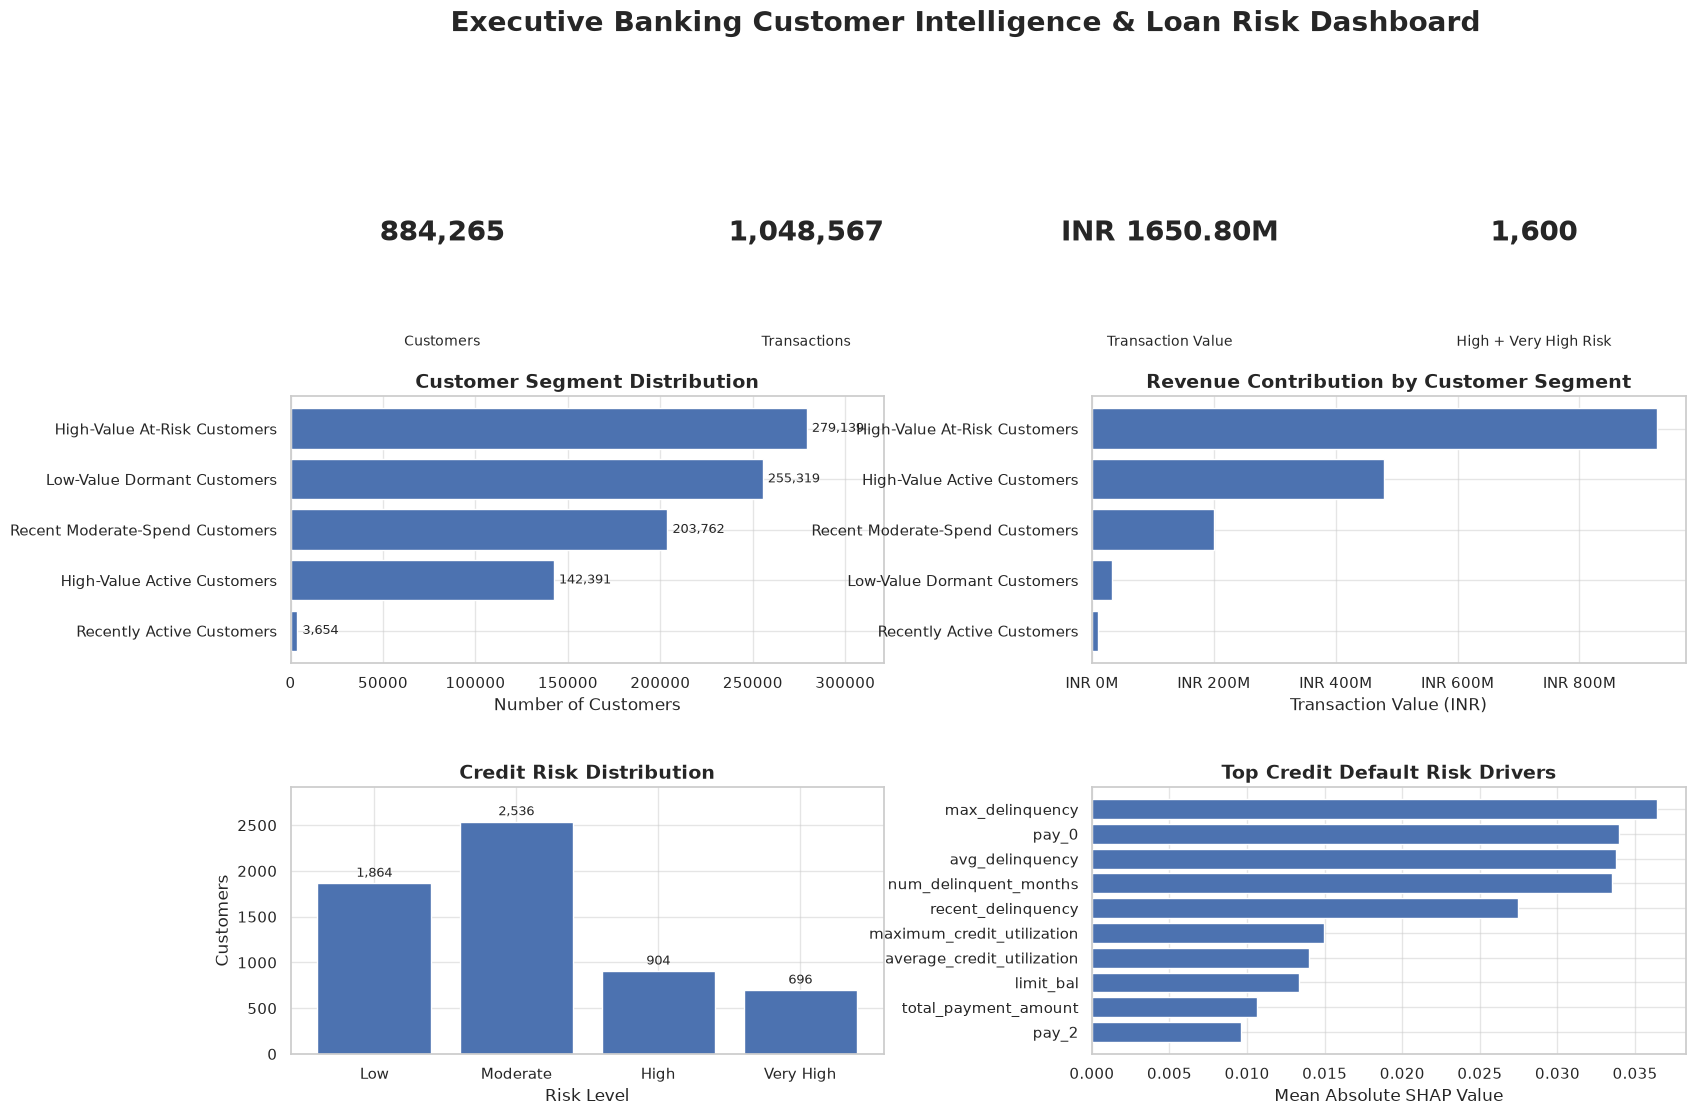

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==========================================
# EXECUTIVE BANKING ANALYTICS DASHBOARD
# ==========================================

plt.rcParams["font.family"] = "DejaVu Sans"

fig = plt.figure(figsize=(18, 12))

gs = fig.add_gridspec(
    3, 2,
    height_ratios=[0.8, 1.5, 1.5],
    hspace=0.55,
    wspace=0.35
)

# ==========================================
# KPI CARDS
# ==========================================

kpi_values = [
    ("Customers", f"{customer_kpis['total_customers']:,}"),
    ("Transactions", f"{customer_kpis['total_transactions']:,}"),
    ("Transaction Value", f"INR {customer_kpis['total_transaction_value_inr']/1e6:.2f}M"),
    ("High + Very High Risk", f"{credit_kpis['high_risk_customers']:,}")
]

for i, (label, value) in enumerate(kpi_values):

    ax = fig.add_subplot(3, 4, i + 1)

    ax.text(
        0.5, 0.62,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5, 0.22,
        label,
        ha="center",
        va="center",
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)


# ==========================================
# 1. CUSTOMER SEGMENT DISTRIBUTION
# ==========================================

ax1 = fig.add_subplot(gs[1, 0])

segment_plot = (
    customer_master["segment"]
    .value_counts()
    .sort_values(ascending=True)
)

ax1.barh(
    segment_plot.index,
    segment_plot.values
)

ax1.set_title(
    "Customer Segment Distribution",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("Number of Customers")

# Add labels with formatting
for i, value in enumerate(segment_plot.values):

    ax1.text(
        value + segment_plot.values.max() * 0.01,
        i,
        f"{value:,}",
        va="center",
        fontsize=9
    )

ax1.set_xlim(
    0,
    segment_plot.values.max() * 1.15
)


# ==========================================
# 2. REVENUE CONTRIBUTION
# ==========================================

ax2 = fig.add_subplot(gs[1, 1])

revenue_plot = (
    segment_kpis
    .sort_values("total_spending_inr", ascending=True)
)

ax2.barh(
    revenue_plot["segment"],
    revenue_plot["total_spending_inr"]
)

ax2.set_title(
    "Revenue Contribution by Customer Segment",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Transaction Value (INR)")

ax2.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"INR {x/1e6:.0f}M")
)


# ==========================================
# 3. CREDIT RISK DISTRIBUTION
# ==========================================

ax3 = fig.add_subplot(gs[2, 0])

risk_order = [
    "Low",
    "Moderate",
    "High",
    "Very High"
]

risk_plot = risk_summary.reindex(risk_order)

bars = ax3.bar(
    risk_plot.index,
    risk_plot["customers"]
)

ax3.set_title(
    "Credit Risk Distribution",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Risk Level")
ax3.set_ylabel("Customers")

# Add customer counts
for bar, value in zip(bars, risk_plot["customers"]):

    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        value + 40,
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax3.set_ylim(
    0,
    risk_plot["customers"].max() * 1.15
)


# ==========================================
# 4. TOP CREDIT RISK DRIVERS
# ==========================================

ax4 = fig.add_subplot(gs[2, 1])

driver_plot = (
    top_risk_drivers
    .sort_values("mean_abs_shap", ascending=True)
)

ax4.barh(
    driver_plot["feature"],
    driver_plot["mean_abs_shap"]
)

ax4.set_title(
    "Top Credit Default Risk Drivers",
    fontsize=14,
    fontweight="bold"
)

ax4.set_xlabel("Mean Absolute SHAP Value")


# ==========================================
# MAIN TITLE
# ==========================================

fig.suptitle(
    "Executive Banking Customer Intelligence & Loan Risk Dashboard",
    fontsize=20,
    fontweight="bold",
    y=0.98
)


# ==========================================
# SAVE
# ==========================================

plt.savefig(
    "executive_banking_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()